In [2]:
import os

print(os.getcwd())
print(os.listdir("../data"))

C:\Users\gurje\Superstore_Sales_Analysis\notebook
['.ipynb_checkpoints', 'Sample - Superstore.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# Dataset shape
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types and missing values
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nNumerical Summary:")
display(df.describe())

Rows and Columns: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
# Make a copy so the original dataset remains unchanged
df_clean = df.copy()

# Convert date columns to datetime
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

# Check for duplicate rows
print("Duplicate rows:", df_clean.duplicated().sum())

# Check missing values
print("\nMissing values:")
print(df_clean.isnull().sum().sum())

# Check data types after conversion
print("\nDate column types:")
print(df_clean[["Order Date", "Ship Date"]].dtypes)

# Display cleaned data
df_clean.head()

Duplicate rows: 0

Missing values:
0

Date column types:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
# Create useful time-based columns
df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month
df_clean["Month Name"] = df_clean["Order Date"].dt.month_name()
df_clean["Year-Month"] = df_clean["Order Date"].dt.to_period("M").astype(str)

# Calculate shipping days
df_clean["Shipping Days"] = (
    df_clean["Ship Date"] - df_clean["Order Date"]
).dt.days

# Check the new columns
df_clean[
    ["Order Date", "Ship Date", "Year", "Month", 
     "Month Name", "Year-Month", "Shipping Days"]
].head()

,Order Date,Ship Date,Year,Month,Month Name,Year-Month,Shipping Days
0,2016-11-08,2016-11-11,2016,11,November,2016-11,3
1,2016-11-08,2016-11-11,2016,11,November,2016-11,3
2,2016-06-12,2016-06-16,2016,6,June,2016-06,4
3,2015-10-11,2015-10-18,2015,10,October,2015-10,7
4,2015-10-11,2015-10-18,2015,10,October,2015-10,7


In [8]:
# Calculate key business KPIs

total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()
total_quantity = df_clean["Quantity"].sum()
average_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

print("========== BUSINESS KPIs ==========")
print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Profit      : ${total_profit:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Total Quantity    : {total_quantity:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Profit Margin     : {profit_margin:.2f}%")

========== BUSINESS KPIs ==========
Total Sales       : $2,297,200.86
Total Profit      : $286,397.02
Total Orders      : 5,009
Total Customers   : 793
Total Quantity    : 37,873
Average Order Value: $458.61
Profit Margin     : 12.47%


In [9]:
yearly_performance = (
    df_clean.groupby("Year")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

display(yearly_performance)

,Year,Sales,Profit
0,2014,484247.4981,49543.9741
1,2015,470532.5090,61618.6037
2,2016,609205.5980,81795.1743
3,2017,733215.2552,93439.2696


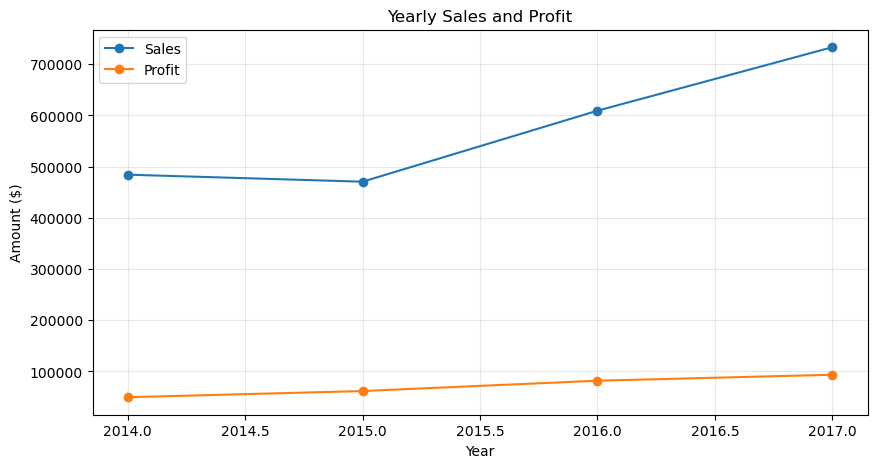

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_performance["Year"],
    yearly_performance["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    yearly_performance["Year"],
    yearly_performance["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Yearly Sales and Profit")
plt.xlabel("Year")
plt.ylabel("Amount ($)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [11]:
category_performance = (
    df_clean.groupby("Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

display(category_performance)

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


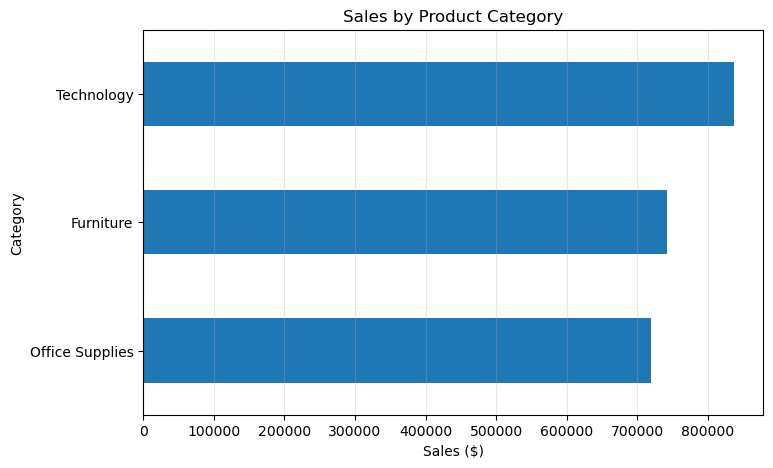

In [12]:
plt.figure(figsize=(8, 5))

category_performance["Sales"].sort_values().plot(
    kind="barh"
)

plt.title("Sales by Product Category")
plt.xlabel("Sales ($)")
plt.ylabel("Category")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [15]:
subcategory_performance = (
    df_clean.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

display(subcategory_performance)

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


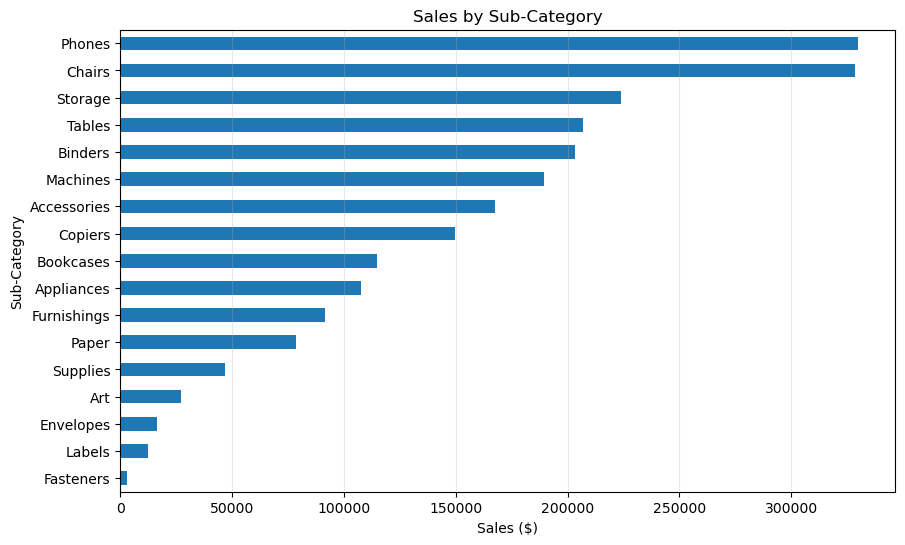

In [16]:
plt.figure(figsize=(10, 6))

subcategory_performance["Sales"].sort_values().plot(
    kind="barh"
)

plt.title("Sales by Sub-Category")
plt.xlabel("Sales ($)")
plt.ylabel("Sub-Category")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [17]:
profit_by_subcategory = (
    df_clean.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)

display(profit_by_subcategory)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

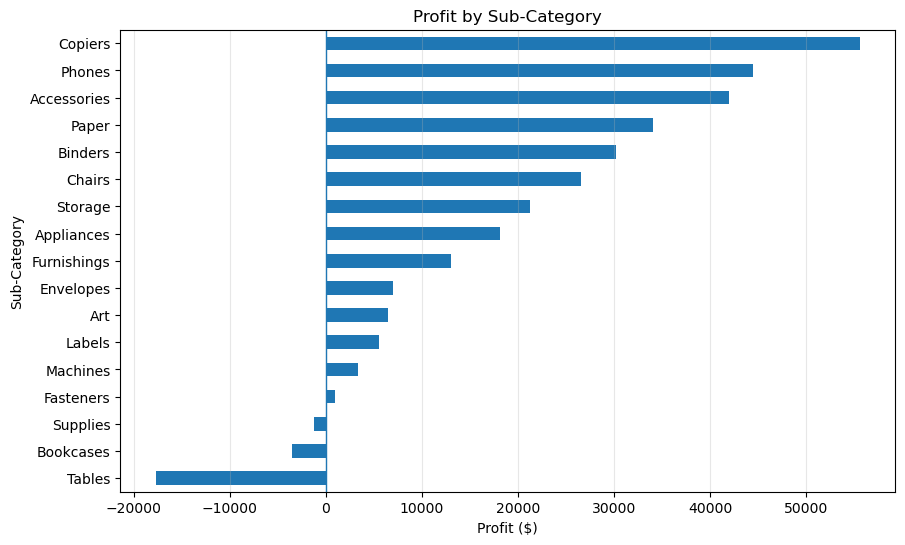

In [18]:
plt.figure(figsize=(10, 6))

profit_by_subcategory.plot(kind="barh")

plt.title("Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")
plt.axvline(0, linewidth=1)
plt.grid(axis="x", alpha=0.3)

plt.show()

In [19]:
discount_profit = (
    df_clean.groupby("Discount")["Profit"]
    .agg(["sum", "mean", "count"])
    .reset_index()
)

discount_profit.columns = [
    "Discount", "Total Profit", "Average Profit", "Number of Records"
]

display(discount_profit)

,Discount,Total Profit,Average Profit,Number of Records
0,0.00,320987.6032,66.900292,4798
1,0.10,9029.1770,96.055074,94
2,0.15,1418.9915,27.288298,52
3,0.20,90337.3060,24.702572,3657
4,0.30,-10369.2774,-45.679636,227
5,0.32,-2391.1377,-88.560656,27
6,0.40,-23057.0504,-111.927429,206
7,0.45,-2493.1111,-226.646464,11
8,0.50,-20506.4281,-310.703456,66
9,0.60,-5944.6552,-43.077212,138


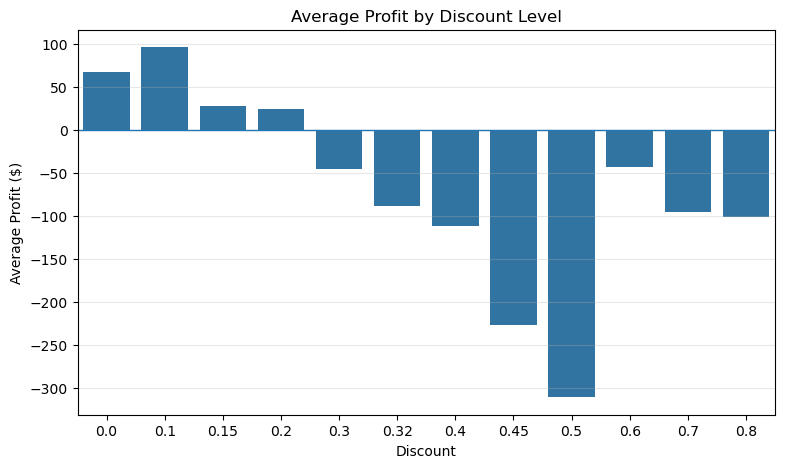

In [20]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=discount_profit,
    x="Discount",
    y="Average Profit"
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit ($)")
plt.axhline(0, linewidth=1)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [21]:
region_performance = (
    df_clean.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

display(region_performance)

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


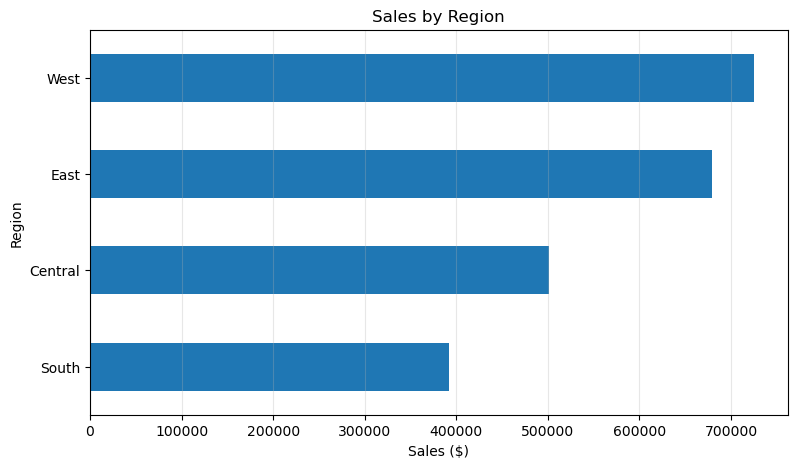

In [22]:
plt.figure(figsize=(9, 5))

region_performance["Sales"].sort_values().plot(
    kind="barh"
)

plt.title("Sales by Region")
plt.xlabel("Sales ($)")
plt.ylabel("Region")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [23]:
segment_performance = (
    df_clean.groupby("Segment")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

display(segment_performance)

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


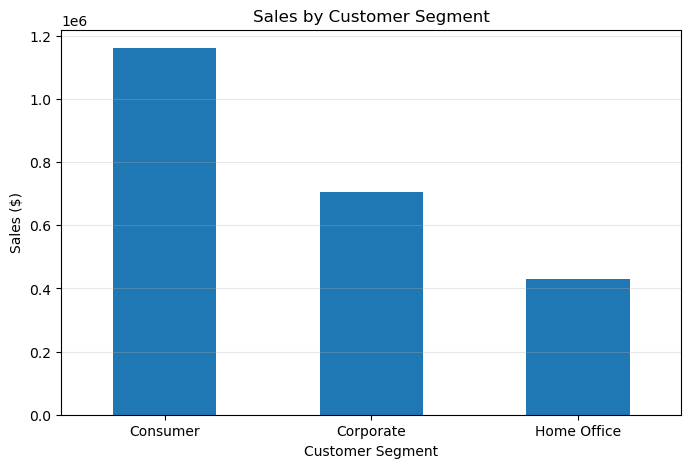

In [24]:
plt.figure(figsize=(8, 5))

segment_performance["Sales"].plot(
    kind="bar"
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [25]:
top_products = (
    df_clean.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_products)


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

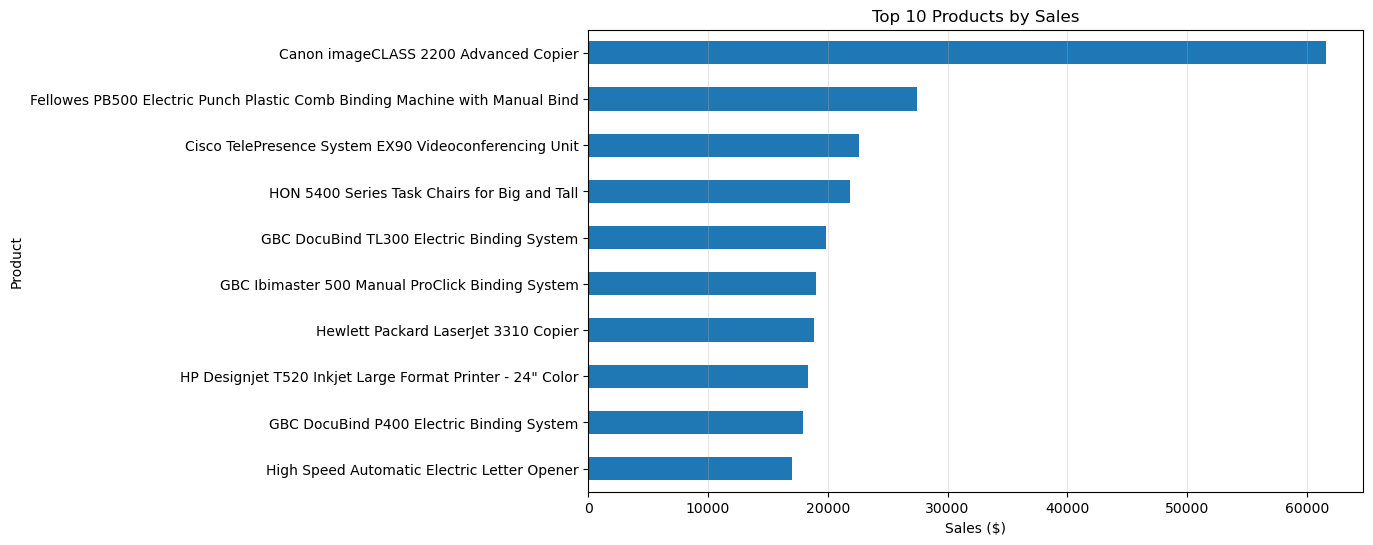

In [26]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [27]:
top_customers = (
    df_clean.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

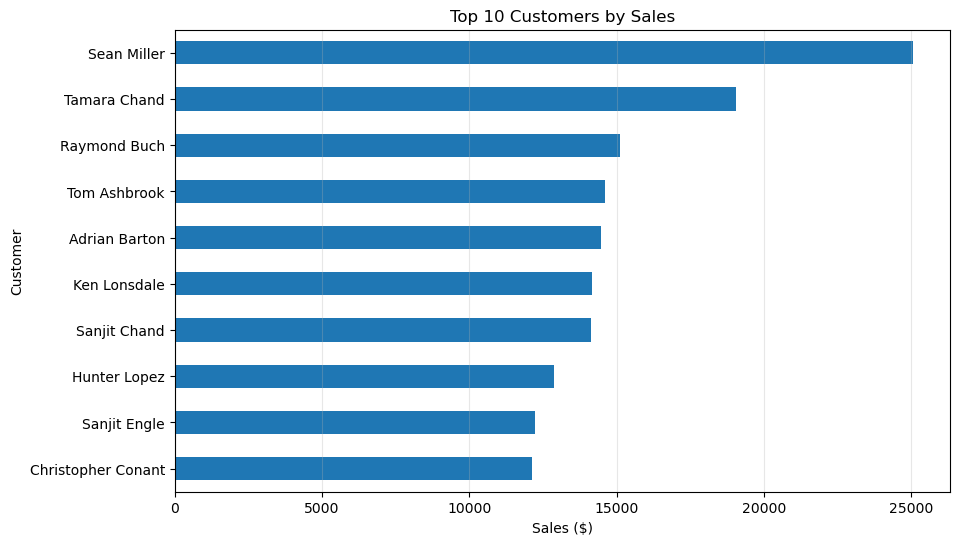

In [28]:
plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Customer")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [29]:
import sqlite3

# Create SQLite database
conn = sqlite3.connect("../data/superstore.db")

# Save cleaned dataset into SQL table
df_clean.to_sql("sales", conn, if_exists="replace", index=False)

print("SQL database created successfully!")
print("Table name: sales")

SQL database created successfully!
Table name: sales


In [30]:
# SQL Query 1: Overall Sales and Profit

query = """
SELECT
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(DISTINCT "Order ID") AS Total_Orders,
    COUNT(DISTINCT "Customer ID") AS Total_Customers
FROM sales;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Total_Sales,Total_Profit,Total_Orders,Total_Customers
0,2297200.86,286397.02,5009,793


In [31]:
# SQL Query 2: Sales and Profit by Category

query = """
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Category,Total_Sales,Total_Profit
0,Technology,836154.03,145454.95
1,Furniture,741999.80,18451.27
2,Office Supplies,719047.03,122490.80


In [32]:
query = """
SELECT
    "Product Name",
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM sales
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Product Name,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.82
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48
3,HON 5400 Series Task Chairs for Big and Tall,21870.58
4,GBC DocuBind TL300 Electric Binding System,19823.48
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.50
6,Hewlett Packard LaserJet 3310 Copier,18839.69
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.90
8,GBC DocuBind P400 Electric Binding System,17965.07
9,High Speed Automatic Electric Letter Opener,17030.31


In [33]:
query = """
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM sales
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Region,Total_Sales,Total_Profit
0,West,725457.82,108418.45
1,East,678781.24,91522.78
2,South,391721.91,46749.43
3,Central,501239.89,39706.36


In [34]:
query = """
SELECT
    Segment,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(DISTINCT "Customer ID") AS Total_Customers
FROM sales
GROUP BY Segment
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Segment,Total_Sales,Total_Profit,Total_Customers
0,Consumer,1161401.34,134119.21,409
1,Corporate,706146.37,91979.13,236
2,Home Office,429653.15,60298.68,148


In [35]:
query = """
SELECT
    "Product Name",
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM sales
GROUP BY "Product Name"
HAVING SUM(Profit) < 0
ORDER BY Total_Profit ASC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Product Name,Total_Sales,Total_Profit
0,Cubify CubeX 3D Printer Double Head Print,11099.96,-8879.97
1,Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97
2,Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.64,-2876.12
4,Bush Advantage Collection Racetrack Conference...,9544.73,-1934.40
5,GBC DocuBind P400 Electric Binding System,17965.07,-1878.17
6,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08
7,Martin Yale Chadless Opener Electric Letter Op...,16656.20,-1299.18
8,Balt Solid Wood Round Tables,6518.75,-1201.06
9,BoxOffice By Design Rectangular and Half-Moon ...,1706.25,-1148.44


In [36]:
query = """
SELECT
    Discount,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(AVG(Profit), 2) AS Average_Profit
FROM sales
GROUP BY Discount
ORDER BY Discount;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Discount,Total_Sales,Total_Profit,Average_Profit
0,0.00,1087908.47,320987.60,66.90
1,0.10,54369.35,9029.18,96.06
2,0.15,27558.52,1418.99,27.29
3,0.20,764594.37,90337.31,24.70
4,0.30,103226.65,-10369.28,-45.68
5,0.32,14493.46,-2391.14,-88.56
6,0.40,116417.78,-23057.05,-111.93
7,0.45,5484.97,-2493.11,-226.65
8,0.50,58918.54,-20506.43,-310.70
9,0.60,6644.70,-5944.66,-43.08


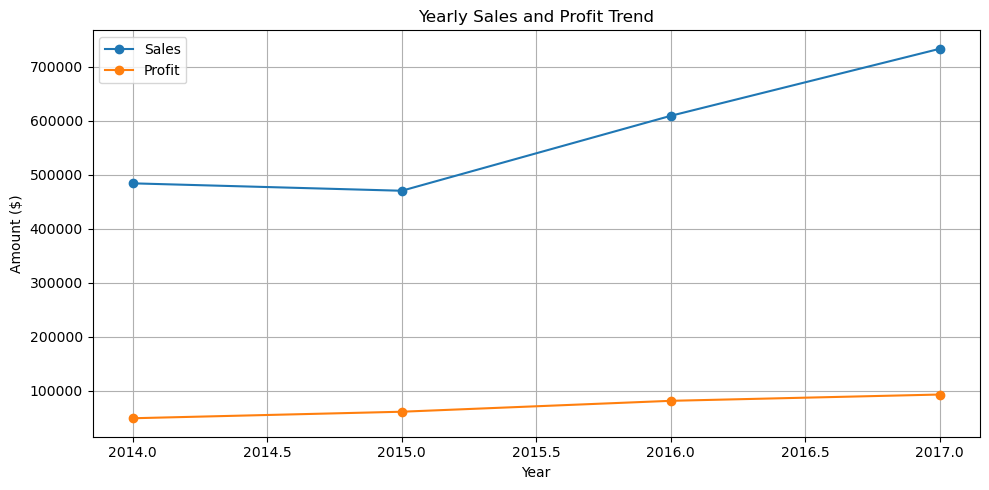

In [37]:
# visualizations
yearly = (
    df_clean.groupby("Year")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(yearly["Year"], yearly["Sales"], marker="o", label="Sales")
plt.plot(yearly["Year"], yearly["Profit"], marker="o", label="Profit")

plt.title("Yearly Sales and Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

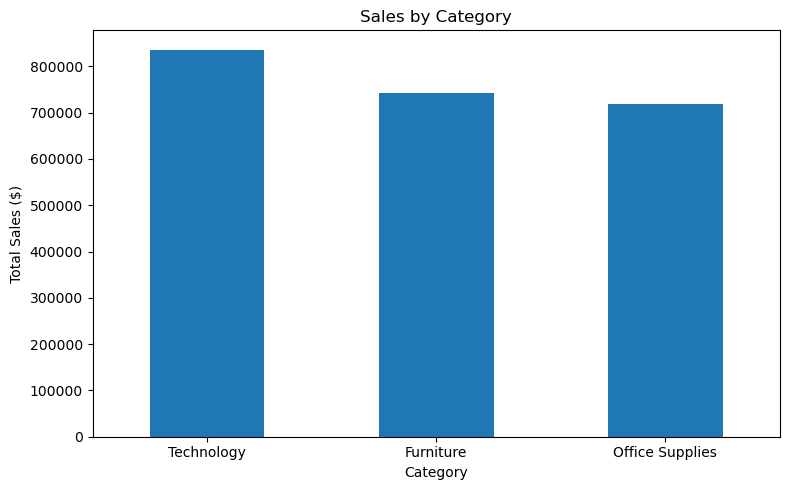

In [38]:
category_sales = (
    df_clean.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

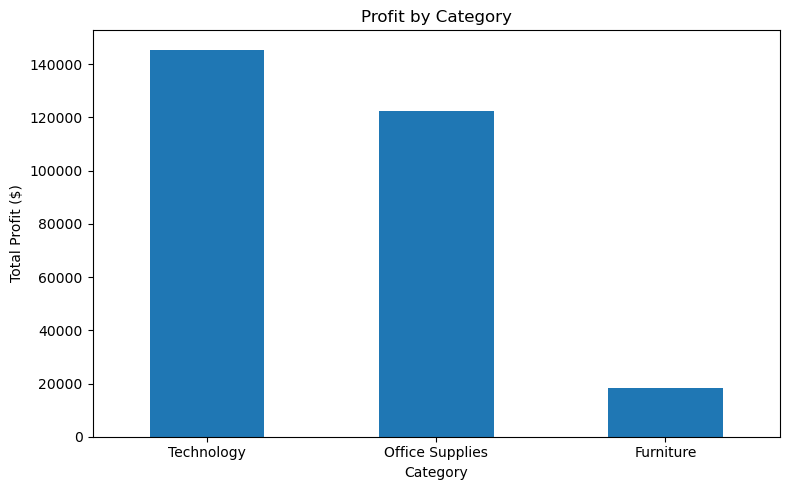

In [39]:
category_profit = (
    df_clean.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

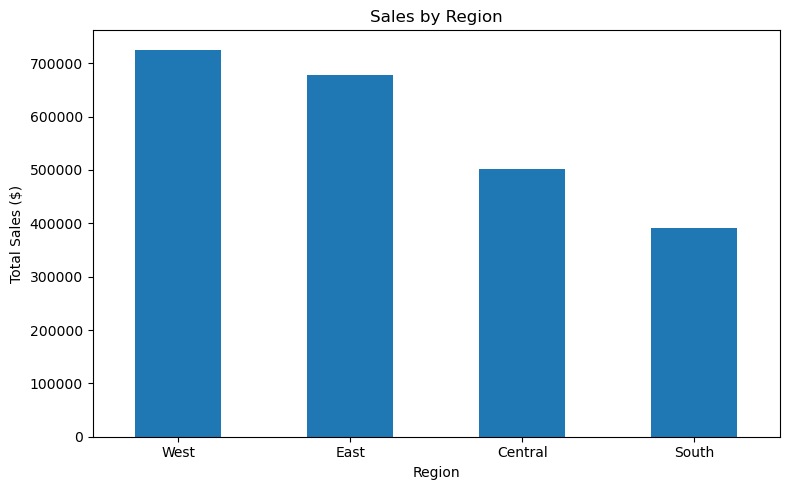

In [40]:
region_sales = (
    df_clean.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

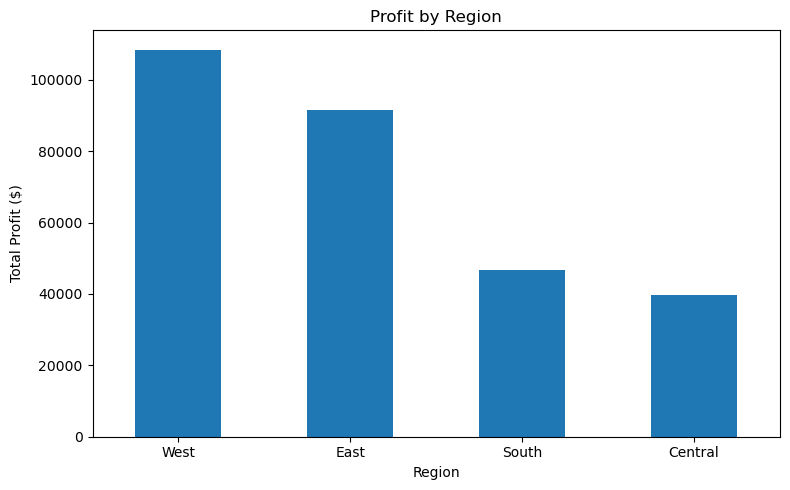

In [41]:
region_profit = (
    df_clean.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

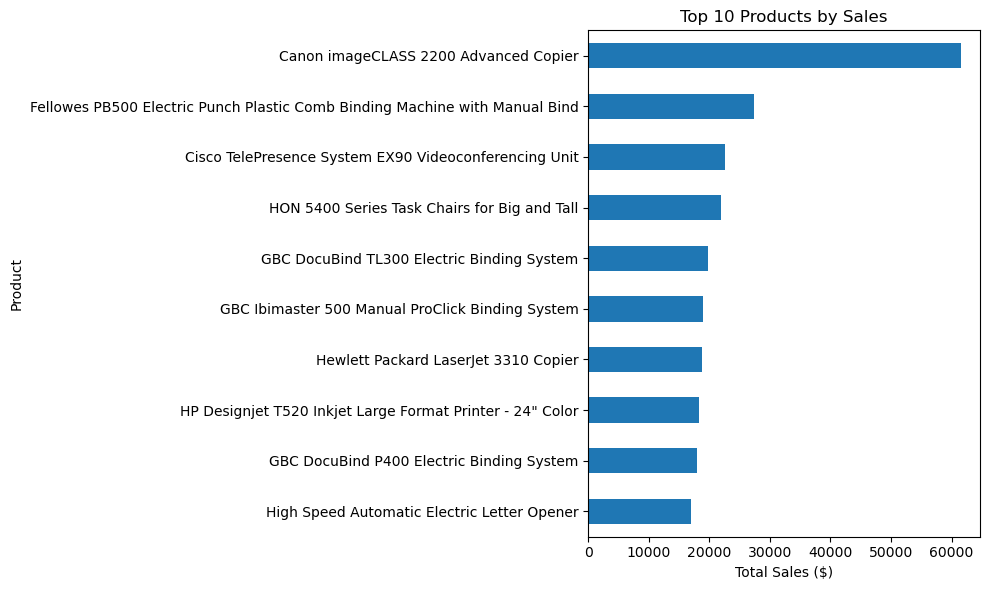

In [42]:
top_products = (
    df_clean.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

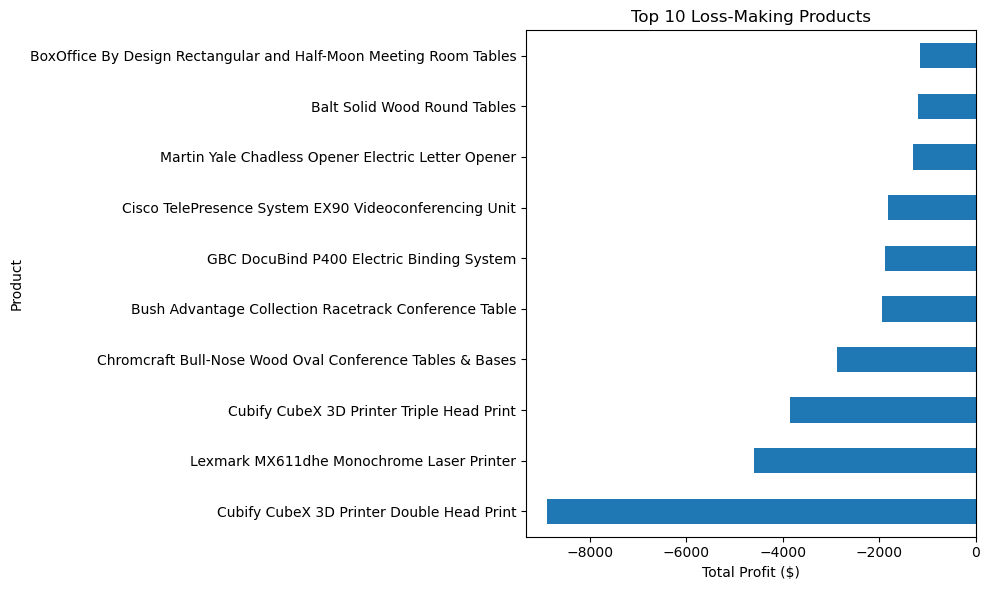

In [43]:
loss_products = (
    df_clean.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10, 6))

loss_products.plot(kind="barh")

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Profit ($)")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

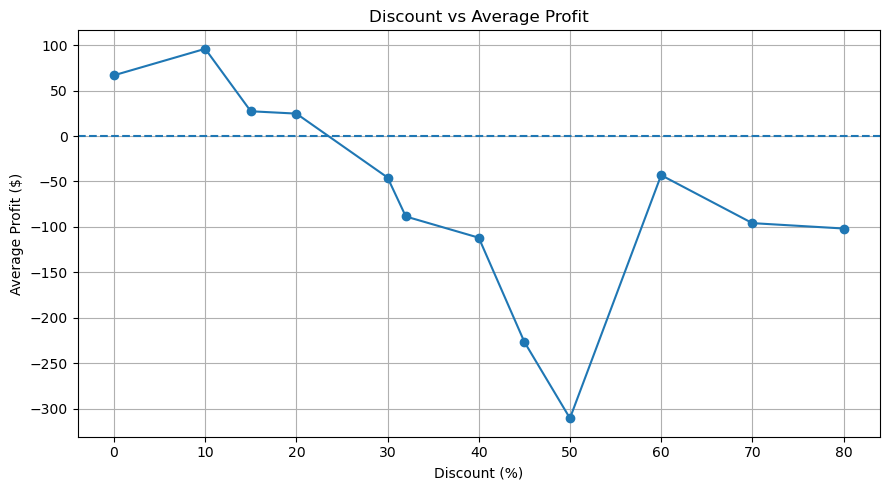

In [44]:
discount_profit = (
    df_clean.groupby("Discount")["Profit"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

plt.plot(
    discount_profit["Discount"] * 100,
    discount_profit["Profit"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Discount vs Average Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Average Profit ($)")
plt.grid(True)
plt.tight_layout()

plt.show()

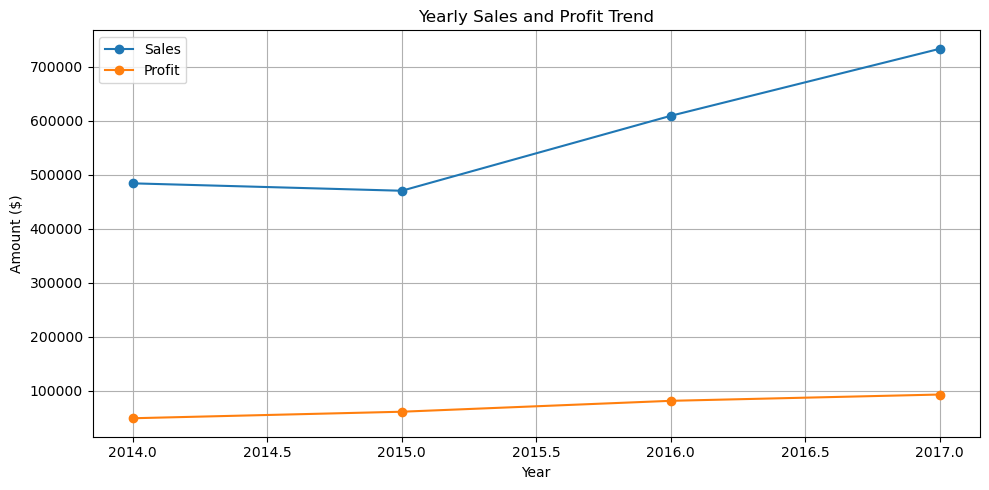

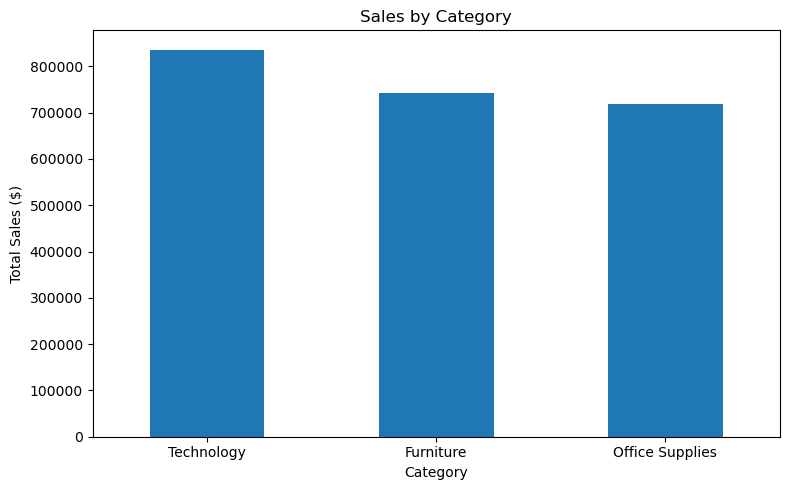

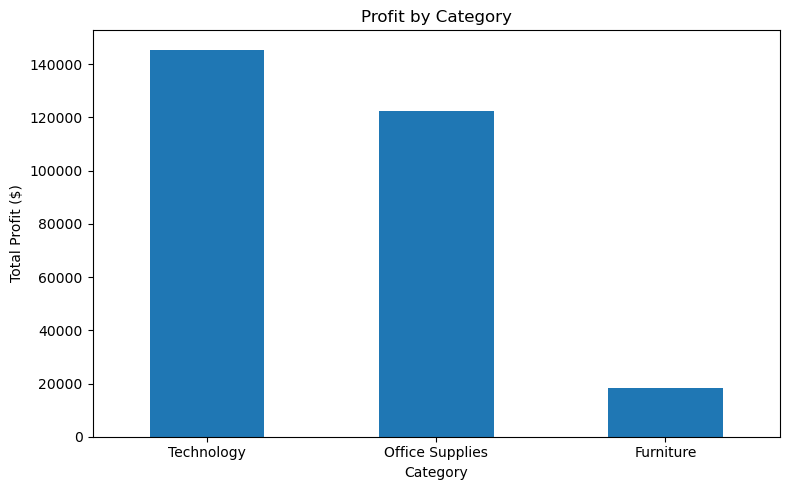

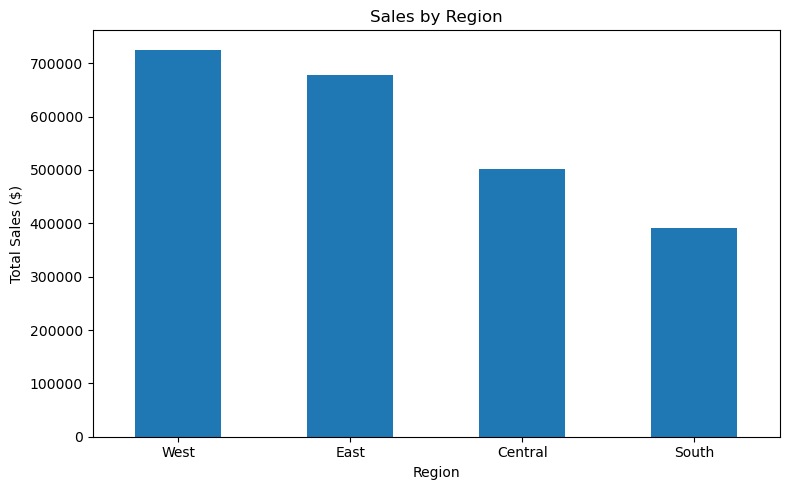

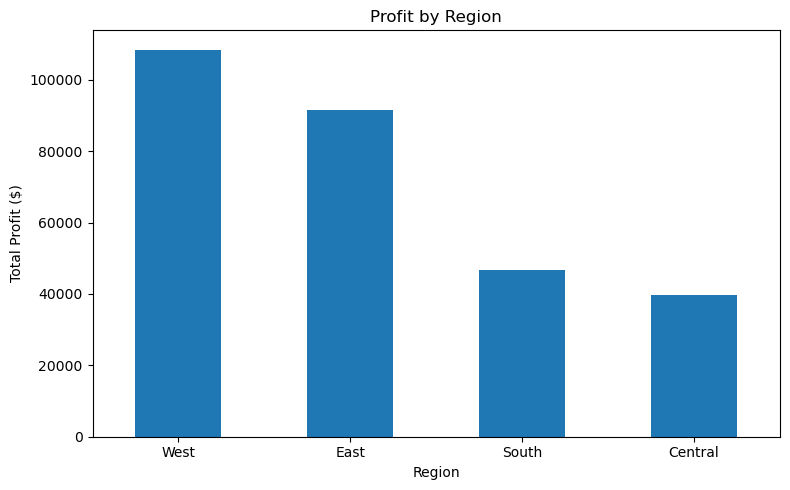

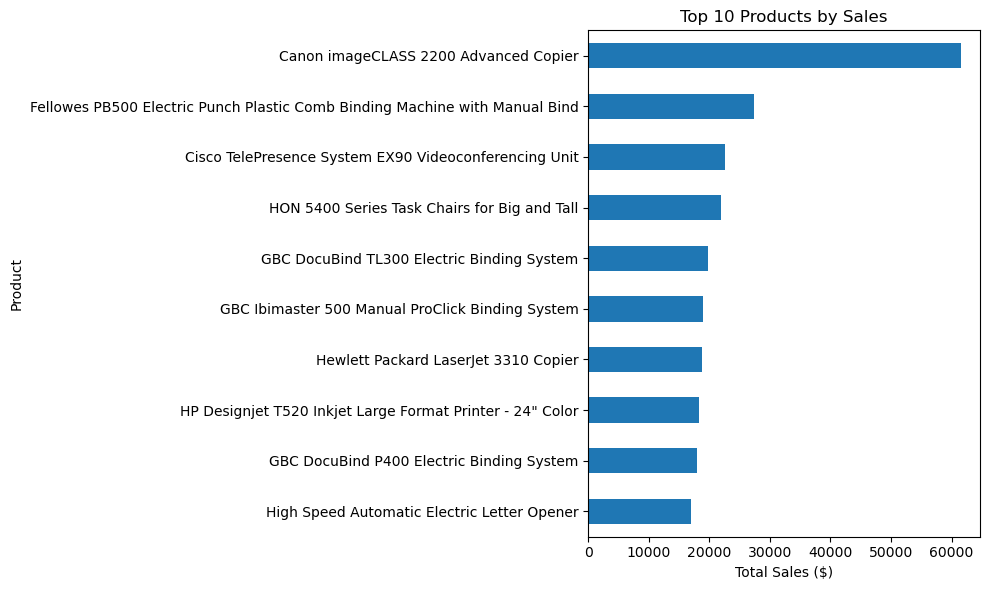

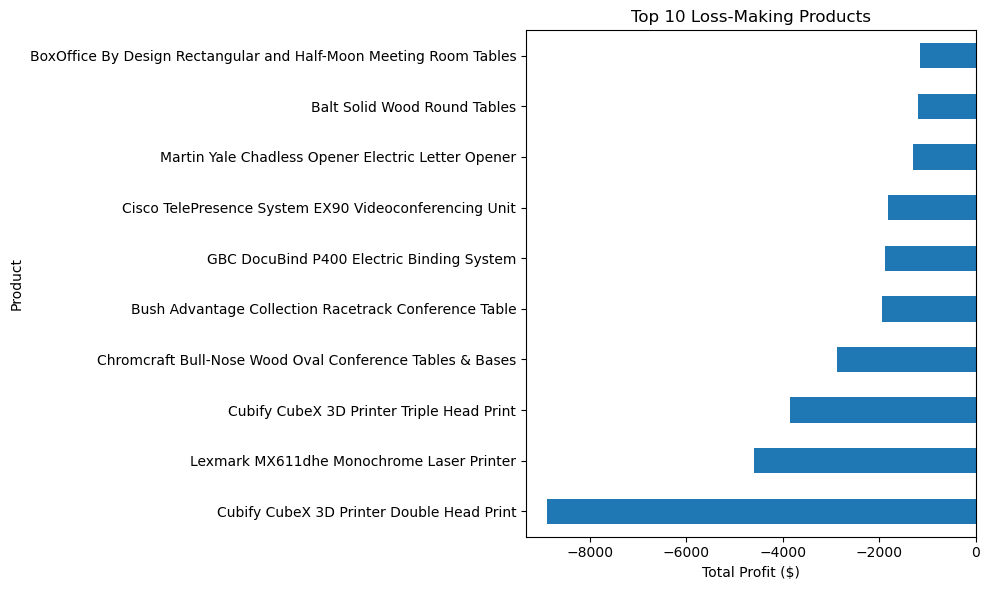

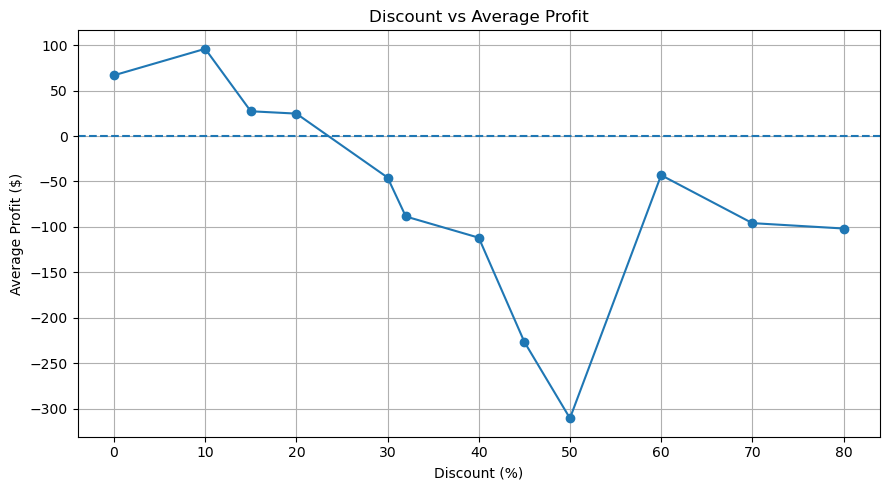

✅ All 8 figures saved successfully!
Location: C:\Users\gurje\Superstore_Sales_Analysis\figures


In [45]:
import os
import matplotlib.pyplot as plt

figures_path = "../figures"
os.makedirs(figures_path, exist_ok=True)

# 1. Yearly Sales & Profit
yearly = df_clean.groupby("Year")[["Sales", "Profit"]].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly["Year"], yearly["Sales"], marker="o", label="Sales")
plt.plot(yearly["Year"], yearly["Profit"], marker="o", label="Profit")
plt.title("Yearly Sales and Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figures_path}/yearly_sales_profit.png", dpi=300)
plt.show()
plt.close()


# 2. Sales by Category
category_sales = df_clean.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{figures_path}/sales_by_category.png", dpi=300)
plt.show()
plt.close()


# 3. Profit by Category
category_profit = df_clean.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_profit.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{figures_path}/profit_by_category.png", dpi=300)
plt.show()
plt.close()


# 4. Sales by Region
region_sales = df_clean.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{figures_path}/sales_by_region.png", dpi=300)
plt.show()
plt.close()


# 5. Profit by Region
region_profit = df_clean.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{figures_path}/profit_by_region.png", dpi=300)
plt.show()
plt.close()


# 6. Top 10 Products
top_products = (
    df_clean.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(f"{figures_path}/top_10_products.png", dpi=300)
plt.show()
plt.close()


# 7. Loss-Making Products
loss_products = (
    df_clean.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10, 6))
loss_products.plot(kind="barh")
plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Profit ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(f"{figures_path}/loss_making_products.png", dpi=300)
plt.show()
plt.close()


# 8. Discount vs Average Profit
discount_profit = (
    df_clean.groupby("Discount")["Profit"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(
    discount_profit["Discount"] * 100,
    discount_profit["Profit"],
    marker="o"
)
plt.axhline(0, linestyle="--")
plt.title("Discount vs Average Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Average Profit ($)")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{figures_path}/discount_vs_profit.png", dpi=300)
plt.show()
plt.close()


print("✅ All 8 figures saved successfully!")
print("Location:", os.path.abspath(figures_path))